# Q2. Can a small classifier on frozen Evo2 representations outperform zero-shot Evo2 scoring for missense variants in previously unseen genes?

An Evo2 1B pilot with **5,000 missense SNVs** and **1,024-base contexts**, using [Q1](Q1-clinvar-split.ipynb)’s frozen splits. Eligibility requires the exact ClinVar `MC` term **`SO:0001583`**, in addition to Q0’s quality and label filters. Multiple consequences are allowed and all gene associations are retained. [Dependencies](../requirements.txt) · [Implementation](src/q2.py) · [Presentation](src/q2_display.py).

The [earlier broad-SNV run](results/archive/broad_snv_before_missense/) is archived. Its feature caches, fitted models and reported scores are separate from this missense experiment.

This pilot uses the pinned **5 September 2026** ClinVar snapshot. Q0’s current **6 July 2026** download is a separate input.

In [1]:
from src import q2, q2_display
q2.settings()

Q1 frozen missense splits · 1,024 bases · Evo2 1B · validation selects C · seed 42


## Frozen input from Q1

Use Q1’s fixed **missense-only** [training VCF](../data/clinvar-train-pilot.vcf) and [validation VCF](../data/clinvar-test-pilot.vcf). Fit on training data; choose C and compare methods on validation. There is no separate test stage.

Q1 samples 5,000 variants from **65,270 eligible missense SNVs** with seed 42, preserving every earlier full-cohort split assignment. It verifies each exported record’s missense annotation and freezes the VCF checksums. [Filters and counts](results/q1/filter_counts.csv) · [Split counts](results/q1/split_counts.csv). The rebuilt files contain **3,658 training** and **1,342 validation variants**.

In [2]:
q2.run_checks()
sequences = q2.load_inputs()

10 model, feature and cache isolation tests passed.


5,000 sampled variants retained; 6 leakage check groups passed.


Loaded 5,000 missense variants from Q1's frozen manifests; model outputs: results/q2/.


[Pilot manifest](results/q1/split_manifest.csv) · [Full-cohort groups](results/q1/full_cohort_groups.csv.gz) · [Protocol](results/q1/protocol.json)

Checks cover recorded relationships and exact contexts. Homology, shared patients, pretraining overlap and annotation circularity remain unresolved.

## Frozen DNA features

Mean-pool `blocks.24`, average strands, concatenate reference and alternate-minus-reference vectors. Zero-shot: negative change in mean log likelihood. Baseline: alleles, reference trinucleotide and GC. Clinical annotations never enter features.

In [3]:
features = q2_display.extract_features(sequences)

## Train and select

Fit scaling and balanced logistic regression on training data only. Choose C from {0.01, 0.1, 1, 10} by validation AUROC.

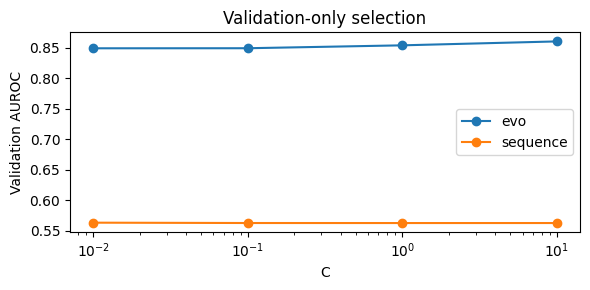

In [4]:
selection = q2.select_models()

## Validation comparison

Compare AUROC and average precision on the same validation data used to choose C. Paired component bootstrap gives 95% intervals; these do not correct selection bias. Unchanged reruns reuse saved results.

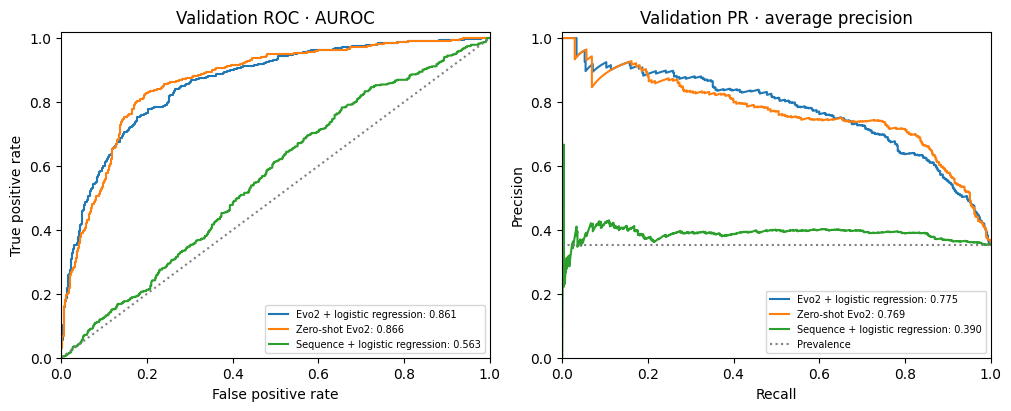

Evo2 classifier AUROC is not clearly different from zero-shot in this pilot: Δ=-0.005, 95% CI [-0.022, +0.011].
Validation also selects C. These development metrics and intervals are not independent final test estimates.


In [5]:
result = q2_display.report_validation()

Validation includes previously evaluated variants. Final performance claims require a new untouched holdout. Generated files: `results/q2/`.

## Conclusion

In [6]:
q2.show_conclusion(result)

**This pilot does not show a clear validation improvement over zero-shot.** AUROC: **0.861** versus **0.866** (difference 95% CI **[-0.022, +0.011]**). The same validation data selects C; an independent final test is still needed.